# Principal Component Analysis

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
#1) Scale the values
#Standardization
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("ieee.csv")
df.head()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [3]:
from sklearn.decomposition import PCA # PCA for dimensionality reduction
pca  = PCA(n_components =2) #finally how at last how many features you want
data_pca = pca.fit_transform(scaled_data)
pca.explained_variance_

array([3.32405685, 1.50272694])

Text(0, 0.5, 'PCA2')

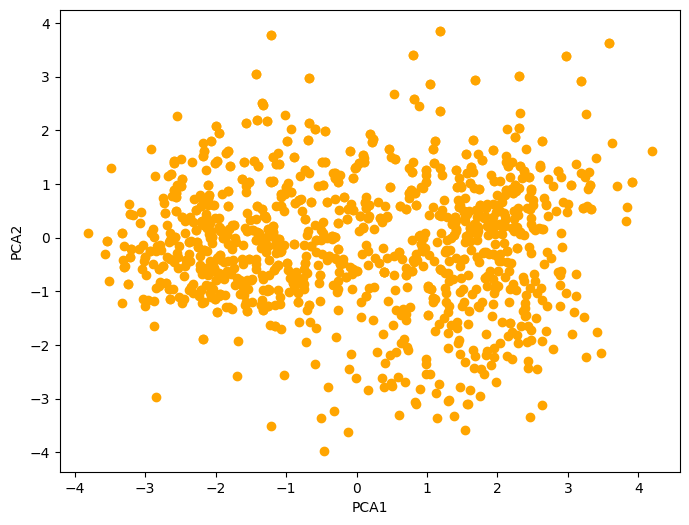

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(data_pca[:,0],data_pca[:,1],color="orange")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
# plt.xlim(0, 20)   # or (-20, 20)
# plt.ylim(-20, 20)

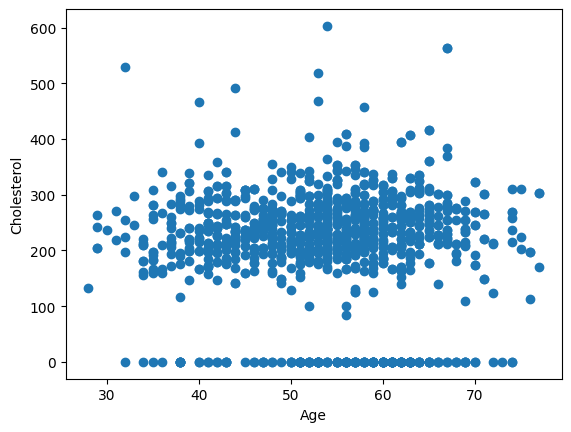

In [6]:
# Outlier detection
plt.scatter(df['age'],df['cholesterol'])
plt.xlabel("Age")
plt.ylabel("Cholesterol")
#plt.title("Age v/s Cholesterol colored by Target")
#plt.colorbar(label='Target')
plt.show()

In [12]:
from sklearn.ensemble import IsolationForest
clf = IsolationForest(contamination=0.2,random_state=42)
clf.fit(df)
predictions = clf.predict(df)
index = np.where(predictions==-1)

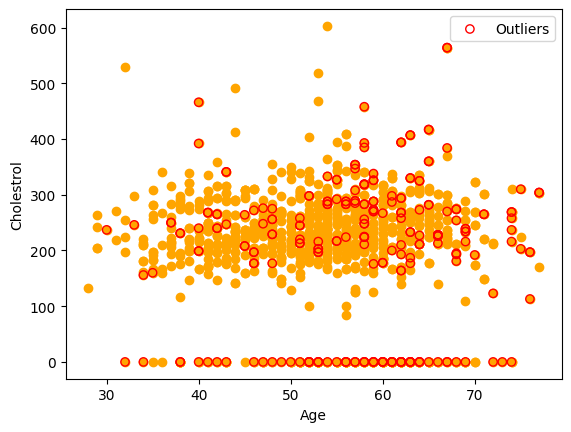

In [13]:
plt.scatter(df['age'],df['cholesterol'],color='orange')
plt.scatter(df.loc[index,'age'],df.loc[index,'cholesterol'],edgecolors='red',facecolors='none',label='Outliers')
plt.xlabel('Age')
plt.ylabel('Cholestrol')
plt.legend()
plt.show()

# DB Scan

In [17]:
from sklearn.cluster import DBSCAN

In [18]:
x=df[['age','cholesterol']].values
dbscan=DBSCAN(eps=0.5,min_samples=5).fit(x)
dbscan.labels_

array([-1, -1, -1, ..., -1, -1, -1], shape=(1190,))

In [19]:
df['Clusters']=dbscan.labels_
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,st slope,target,Clusters
0,40,1,2,140,289,0,0,172,0,0.0,1,0,-1
1,49,0,3,160,180,0,0,156,0,1.0,2,1,-1
2,37,1,2,130,283,0,1,98,0,0.0,1,0,-1
3,48,0,4,138,214,0,0,108,1,1.5,2,1,-1
4,54,1,3,150,195,0,0,122,0,0.0,1,0,-1


In [20]:
index1=np.where(predictions==-1)
index1

(array([  38,   87,  102,  103,  112,  115,  117,  118,  119,  120,  123,
         166,  186,  196,  200,  216,  243,  248,  279,  283,  295,  296,
         298,  300,  304,  306,  308,  310,  313,  314,  315,  316,  319,
         320,  321,  323,  324,  325,  326,  329,  330,  331,  332,  334,
         336,  337,  338,  339,  340,  341,  342,  353,  356,  366,  373,
         376,  384,  397,  398,  399,  400,  401,  403,  408,  410,  411,
         412,  416,  421,  424,  425,  426,  433,  435,  441,  450,  451,
         456,  470,  476,  478,  480,  481,  482,  483,  484,  492,  493,
         497,  499,  505,  508,  509,  514,  516,  517,  519,  538,  542,
         544,  545,  548,  550,  554,  557,  560,  574,  583,  586,  590,
         593,  595,  606,  607,  612,  615,  618,  621,  626,  634,  635,
         636,  641,  646,  648,  650,  652,  654,  660,  669,  674,  681,
         684,  688,  690,  693,  704,  720,  727,  734,  735,  736,  740,
         752,  760,  761,  765,  766, 

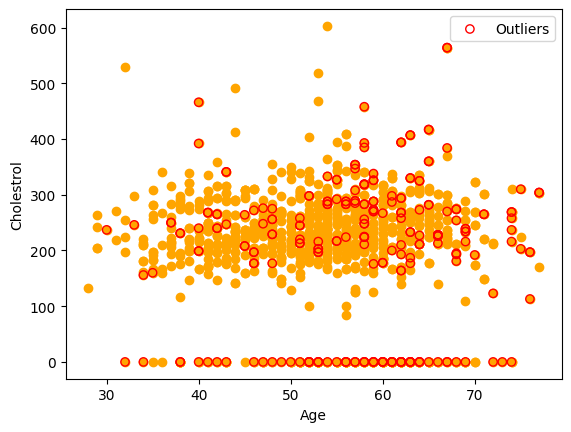

In [21]:
plt.scatter(df['age'],df['cholesterol'],color='orange')
plt.scatter(df.loc[index1,'age'],df.loc[index1,'cholesterol'],edgecolors='red',facecolors='none',label='Outliers')
plt.xlabel('Age')
plt.ylabel('Cholestrol')
plt.legend()
plt.show()